<a href="https://colab.research.google.com/github/1BM23CS345/6Sem_ML_Lab/blob/main/SupportVectorMachine_Lab7_1BM23CS345.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. SVM Classification on Iris Dataset

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer

# Load the Iris dataset
try:
    iris_df = pd.read_csv('/content/iris (1) (2) - iris (1) (2).csv')
    print("Iris dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'iris.csv' not found. Please ensure the file is in the correct directory.")
    exit()

# Prepare the data
X_iris = iris_df.drop('species', axis=1) # Features
y_iris = iris_df['species'] # Target

# Split data into training and testing sets (80% train, 20% test)
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

print(f"\nIris training data shape: {X_train_iris.shape}")
print(f"Iris testing data shape: {X_test_iris.shape}")

Iris dataset loaded successfully.

Iris training data shape: (120, 4)
Iris testing data shape: (30, 4)


### SVM with RBF Kernel

Accuracy Score (RBF Kernel): 1.0000

Confusion Matrix (RBF Kernel):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


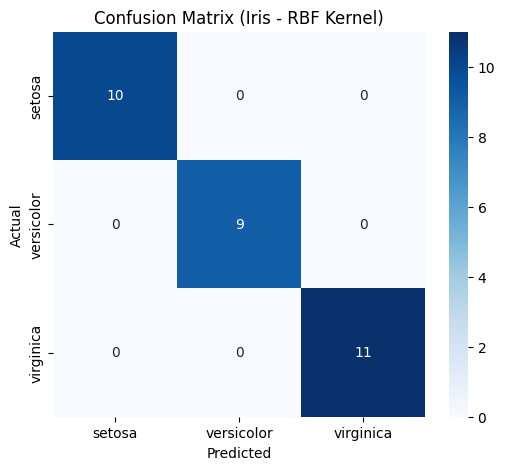

In [7]:
# Build SVM classifier with RBF kernel
svm_rbf = SVC(kernel='rbf', random_state=42)

# Train the model
svm_rbf.fit(X_train_iris, y_train_iris)

# Make predictions on the test data
y_pred_rbf = svm_rbf.predict(X_test_iris)

# Display accuracy score
accuracy_rbf = accuracy_score(y_test_iris, y_pred_rbf)
print(f"Accuracy Score (RBF Kernel): {accuracy_rbf:.4f}")

# Display confusion matrix
conf_matrix_rbf = confusion_matrix(y_test_iris, y_pred_rbf)
print("\nConfusion Matrix (RBF Kernel):\n", conf_matrix_rbf)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rbf, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_rbf.classes_, yticklabels=svm_rbf.classes_)
plt.title('Confusion Matrix (Iris - RBF Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### SVM with Linear Kernel

Accuracy Score (Linear Kernel): 1.0000

Confusion Matrix (Linear Kernel):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


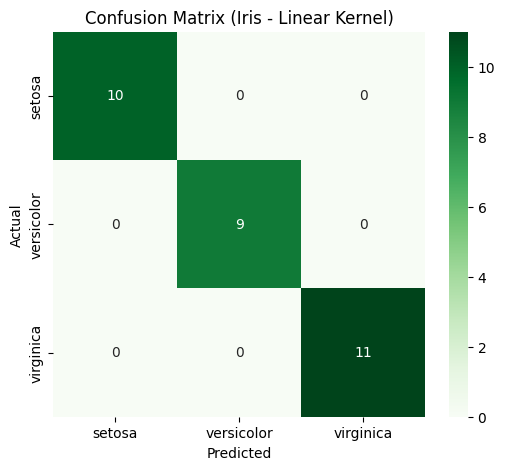

In [8]:
# Build SVM classifier with Linear kernel
svm_linear = SVC(kernel='linear', random_state=42)

# Train the model
svm_linear.fit(X_train_iris, y_train_iris)

# Make predictions on the test data
y_pred_linear = svm_linear.predict(X_test_iris)

# Display accuracy score
accuracy_linear = accuracy_score(y_test_iris, y_pred_linear)
print(f"Accuracy Score (Linear Kernel): {accuracy_linear:.4f}")

# Display confusion matrix
conf_matrix_linear = confusion_matrix(y_test_iris, y_pred_linear)
print("\nConfusion Matrix (Linear Kernel):\n", conf_matrix_linear)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_linear, annot=True, fmt='d', cmap='Greens',
            xticklabels=svm_linear.classes_, yticklabels=svm_linear.classes_)
plt.title('Confusion Matrix (Iris - Linear Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 2. SVM Classification on Letter-recognition (Drug) Dataset

Note: Assuming 'drug.csv' contains data suitable for a multi-class classification problem like letter recognition, with the target variable being the last column. If not, please clarify the dataset structure.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the Drug dataset (assuming it's the 'letter-recognition' data)
try:
    drug_df = pd.read_csv('/content/drug - drug.csv')
    print("Drug dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'drug.csv' not found. Please ensure the file is in the correct directory.")
    exit()

# Assuming the last column is the target variable
X_drug = drug_df.iloc[:, :-1] # All columns except the last
y_drug = drug_df.iloc[:, -1]  # Last column as target

# Split data into training and testing sets (80% train, 20% test)
X_train_drug, X_test_drug, y_train_drug, y_test_drug = train_test_split(X_drug, y_drug, test_size=0.2, random_state=42)

print(f"\nDrug training data shape: {X_train_drug.shape}")
print(f"Drug testing data shape: {X_test_drug.shape}")

Drug dataset loaded successfully.

Drug training data shape: (160, 5)
Drug testing data shape: (40, 5)


Accuracy Score (Drug Dataset - RBF Kernel): 0.6250

Confusion Matrix (Drug Dataset - RBF Kernel):

[[ 0  0  0  6  0]
 [ 0  0  0  3  0]
 [ 0  0  0  4  1]
 [ 0  0  0 10  1]
 [ 0  0  0  0 15]]


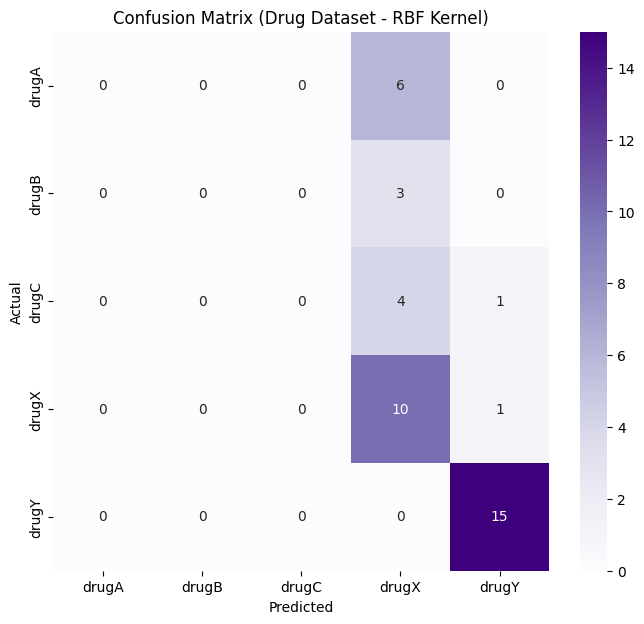

In [8]:
# Build SVM classifier (using RBF kernel, as it's common and generally robust)
# For ROC curve, we need probability estimates, so set probability=True
svm_drug = SVC(kernel='rbf', probability=True, random_state=42)

# Preprocess categorical features using one-hot encoding
X_train_drug_processed = pd.get_dummies(X_train_drug, columns=['Sex', 'BP', 'Cholesterol'], drop_first=True)
X_test_drug_processed = pd.get_dummies(X_test_drug, columns=['Sex', 'BP', 'Cholesterol'], drop_first=True)

# Ensure all columns are aligned after one-hot encoding
X_train_drug_processed, X_test_drug_processed = X_train_drug_processed.align(X_test_drug_processed, join='left', axis=1, fill_value=0)

# Train the model with processed data
svm_drug.fit(X_train_drug_processed, y_train_drug)

# Make predictions on the test data
y_pred_drug = svm_drug.predict(X_test_drug_processed)

# Display accuracy score
accuracy_drug = accuracy_score(y_test_drug, y_pred_drug)
print(f"Accuracy Score (Drug Dataset - RBF Kernel): {accuracy_drug:.4f}")

# Display confusion matrix
conf_matrix_drug = confusion_matrix(y_test_drug, y_pred_drug)
print("\nConfusion Matrix (Drug Dataset - RBF Kernel):\n")
print(conf_matrix_drug)

plt.figure(figsize=(8, 7))
sns.heatmap(conf_matrix_drug, annot=True, fmt='d', cmap='Purples',
            xticklabels=svm_drug.classes_, yticklabels=svm_drug.classes_)
plt.title('Confusion Matrix (Drug Dataset - RBF Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Plotting ROC Curve and AUC Score (Multi-class)

/tmp/ipykernel_6051/2126128252.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('jet', n_classes)


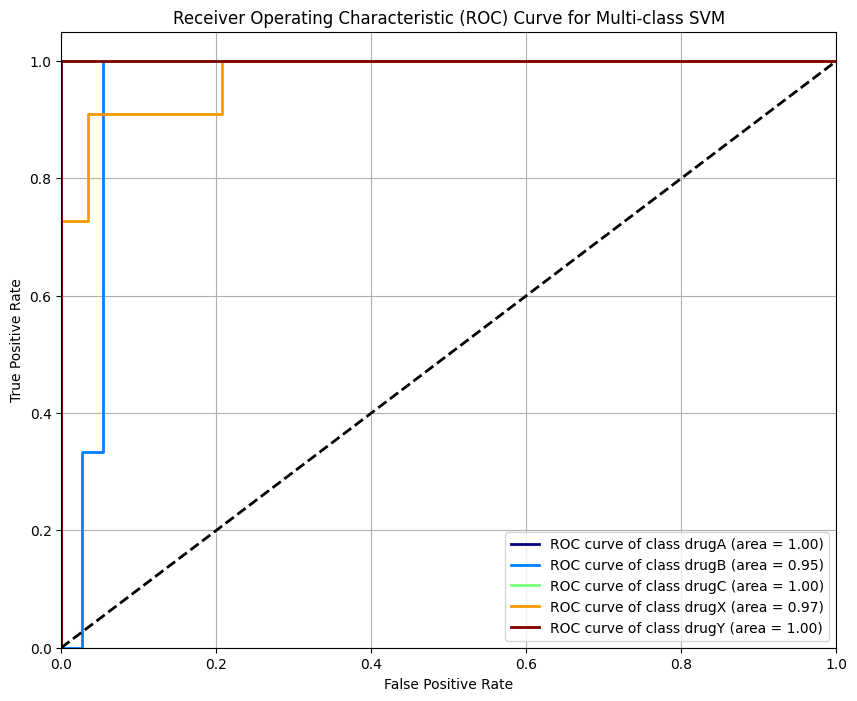

In [11]:

label_binarizer = LabelBinarizer()
y_test_drug_binarized = label_binarizer.fit_transform(y_test_drug)
# Fix: Pass the processed test data (X_test_drug_processed) to predict_proba
y_score_drug = svm_drug.predict_proba(X_test_drug_processed)

n_classes = len(label_binarizer.classes_)

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('jet', n_classes)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_drug_binarized[:, i], y_score_drug[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors(i), lw=2,
             label=f'ROC curve of class {label_binarizer.classes_[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class SVM')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()